
GENERALIZED SIMON'S ALGORITHM
Input secret string: 1011
Mode: Standard Simon problem

CIRCUIT
----------------------------------------------------------------------
     ┌───┐                    ┌───┐        ┌─┐      
q_0: ┤ H ├───────■─────────■──┤ H ├────────┤M├──────
     ├───┤       │  ┌───┐  │  └───┘┌─┐     └╥┘      
q_1: ┤ H ├──■────┼──┤ H ├──┼───────┤M├──────╫───────
     ├───┤  │    │  └───┘  │  ┌───┐└╥┘      ║ ┌─┐   
q_2: ┤ H ├──┼────┼────■────┼──┤ H ├─╫───────╫─┤M├───
     ├───┤  │    │    │    │  └───┘ ║ ┌───┐ ║ └╥┘┌─┐
q_3: ┤ H ├──┼────┼────┼────┼────■───╫─┤ H ├─╫──╫─┤M├
     └───┘┌─┴─┐  │    │    │    │   ║ └───┘ ║  ║ └╥┘
q_4: ─────┤ X ├──┼────┼────┼────┼───╫───────╫──╫──╫─
          └───┘┌─┴─┐┌─┴─┐  │    │   ║       ║  ║  ║ 
q_5: ──────────┤ X ├┤ X ├──┼────┼───╫───────╫──╫──╫─
               └───┘└───┘┌─┴─┐┌─┴─┐ ║       ║  ║  ║ 
q_6: ────────────────────┤ X ├┤ X ├─╫───────╫──╫──╫─
                         └───┘└───┘ ║       ║  ║  ║ 
c: 4/═══════════════════════════════╩══

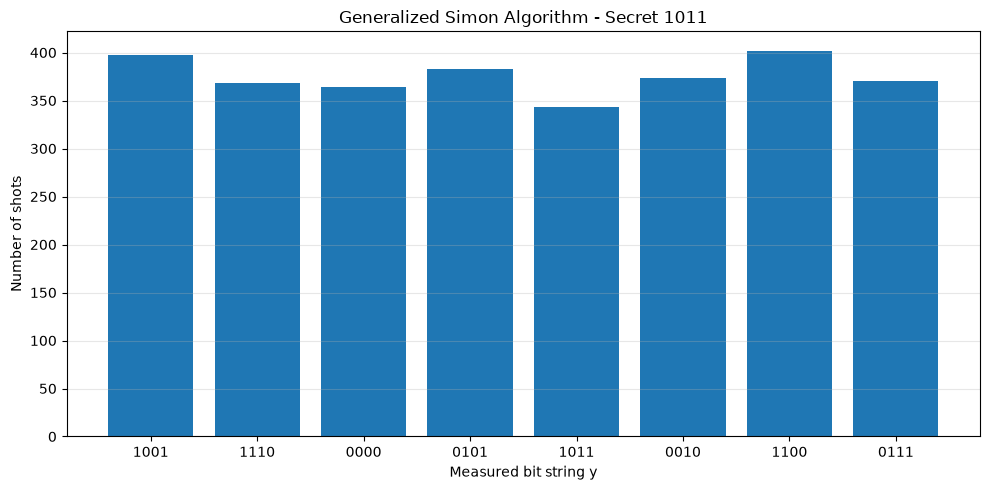

In [1]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

shots = 3000
secret = "1011"

def gf2_rank(matrix, n):
    if not matrix:
        return 0

    matrix = [row[:] for row in matrix]
    rank = 0

    for col in range(n):
        pivot = None

        for row in range(rank, len(matrix)):
            if matrix[row][col] == 1:
                pivot = row
                break

        if pivot is None:
            continue

        matrix[rank], matrix[pivot] = matrix[pivot], matrix[rank]

        for row in range(len(matrix)):
            if row != rank and matrix[row][col] == 1:
                for c in range(col, n):
                    matrix[row][c] ^= matrix[rank][c]

        rank += 1

    return rank

def nullspace(matrix, n):
    matrix = [row[:] for row in matrix]
    rank = 0
    pivot_columns = []

    for col in range(n):
        pivot = None

        for row in range(rank, len(matrix)):
            if matrix[row][col] == 1:
                pivot = row
                break

        if pivot is None:
            continue

        matrix[rank], matrix[pivot] = matrix[pivot], matrix[rank]

        for row in range(len(matrix)):
            if row != rank and matrix[row][col] == 1:
                for c in range(col, n):
                    matrix[row][c] ^= matrix[rank][c]

        pivot_columns.append(col)
        rank += 1

    free_columns = [
        col for col in range(n)
        if col not in pivot_columns
    ]

    basis = []

    for free in free_columns:
        vector = [0] * n
        vector[free] = 1

        for row in range(rank - 1, -1, -1):
            pivot = pivot_columns[row]
            value = 0

            for col in free_columns:
                value ^= matrix[row][col] & vector[col]

            vector[pivot] = value

        basis.append(vector)

    return basis

def create_basis(secret):
    n = len(secret)

    if set(secret) == {"0"}:
        return [
            [1 if i == j else 0 for i in range(n)]
            for j in range(n)
        ]

    s = [int(bit) for bit in secret]
    pivot = s.index(1)
    basis = []

    for j in range(n):
        if j == pivot:
            continue

        row = [0] * n

        if s[j] == 1:
            row[j] = 1
            row[pivot] = 1
        else:
            row[j] = 1

        basis.append(row)

    return basis

def create_generalized_simon_circuit(secret):
    n = len(secret)
    basis = create_basis(secret)
    output_count = len(basis)

    qc = QuantumCircuit(n + output_count, n)

    for q in range(n):
        qc.h(q)

    for output, row in enumerate(basis):
        for input_qubit in range(n):
            if row[input_qubit] == 1:
                qc.cx(input_qubit, n + output)

    for q in range(n):
        qc.h(q)

    qc.measure(range(n), range(n))

    return qc

def recover_secret(counts, n, expected_rank):
    equations = []

    while True:
        previous_rank = gf2_rank(equations, n)

        for state in counts:
            y = [int(bit) for bit in state[::-1]]

            if y == [0] * n:
                continue

            if gf2_rank(equations + [y], n) > gf2_rank(equations, n):
                equations.append(y)

        current_rank = gf2_rank(equations, n)

        if current_rank >= expected_rank:
            break

        break

    basis = nullspace(equations, n)

    return equations, basis

n = len(secret)

qc = create_generalized_simon_circuit(secret)

print("\nGENERALIZED SIMON'S ALGORITHM")
print("=" * 70)
print("Input secret string:", secret)

if set(secret) == {"0"}:
    print("Mode: All-zero edge case")
    expected_rank = n
else:
    print("Mode: Standard Simon problem")
    expected_rank = n - 1

print("\nCIRCUIT")
print("-" * 70)
print(qc.draw())

sampler = StatevectorSampler()

result = sampler.run(
    [qc],
    shots=shots
).result()

counts = result[0].data.c.get_counts()

print("\nMEASUREMENT RESULTS")
print("=" * 70)

for state, count in sorted(counts.items()):
    print(f"{state} : {count}")

equations, recovered_basis = recover_secret(
    counts,
    n,
    expected_rank
)

print("\nEQUATION SYSTEM")
print("=" * 70)

for equation in equations:
    terms = []

    for i, value in enumerate(equation):
        if value == 1:
            terms.append(f"y{i}")

    if terms:
        print(" + ".join(terms), "= 0 (mod 2)")

rank = gf2_rank(equations, n)

print("\nEquation-system rank:", rank)
print("Required rank:", expected_rank)

print("\nRECOVERED NULLSPACE")
print("=" * 70)

for vector in recovered_basis:
    print("".join(map(str, vector)))

if set(secret) == {"0"}:
    recovered = "0" * n

    if rank == n:
        print("\nRecovered secret string:", recovered)
        print("All-zero edge case handled successfully.")
    else:
        print("\nMore independent equations are required.")
else:
    if len(recovered_basis) == 1:
        recovered = "".join(map(str, recovered_basis[0]))

        print("\nRecovered secret string:", recovered)

        if recovered == secret:
            print("Verification: PASSED")
        else:
            print("Verification: FAILED")
    else:
        print("\nThe complete secret could not yet be uniquely determined.")

plt.figure(figsize=(10, 5))

states = list(counts.keys())
values = list(counts.values())

plt.bar(states, values)

plt.xlabel("Measured bit string y")
plt.ylabel("Number of shots")
plt.title(f"Generalized Simon Algorithm - Secret {secret}")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()